# ETL pipeline & database setup (v1.2)
Armani Middle East Trading technical assessment · **Part 1 – Data Engineering, ETL & Database Setup**

Turns the raw `Sample_Data.xlsx` (7,839 rows) into a clean, documented **SQLite star schema**, following the decisions of the EDA (`part1_eda_v1.3.ipynb`):

| Decision | Applied here |
|---|---|
| Dates | Raw data only has `Week` 1–260 → **synthetic calendar** (week 1 starts Monday 2020-01-06), kept as an explicit assumption |
| Capped / zero-inventory / zero-sales rows | **Flagged, never deleted** (`flag_*` columns) |
| Inventory timing | Weekly sales never exceed the **previous row's** inventory, so `stock_available_for_sales` is added and stock-out / stock-limited weeks are flagged |
| Database | **SQLite**, star schema (`dim_product`, `dim_date`, `fact_weekly_sales`) |

```
dataset/Sample_Data.xlsx → EXTRACT (file/schema checks) → stg_sales_raw (untouched copy)
   → TRANSFORM (types, validation → quarantine, de-duplicate, recover sales, flags, recompute KPIs)
   → LOAD (one transaction, rollback on error) → VALIDATE (reconciliation, FK, formula checks)
   → part1_etl_pipeline_v1.2/  armani_trade_v1.2.db · schema_v1.2.sql · etl_results_v1.2.xlsx · figures · log
```

In [1]:
import json
import logging
import re
import sqlite3
import sys
import time
from contextlib import contextmanager
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False})

VERSION = "v1.2"                     # appended to the name of every generated file
HERE = Path.cwd()
DATA = HERE / "dataset" / "Sample_Data.xlsx"          # local only, not in git
OUT = HERE / "part1_etl_pipeline_v1.2"                            # created by this notebook
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)
DB_PATH = OUT / f"armani_trade_{VERSION}.db"
SQL_PATH = OUT / f"schema_{VERSION}.sql"
XLSX_PATH = OUT / f"etl_results_{VERSION}.xlsx"
LOG_PATH = OUT / f"etl_run_{VERSION}.log"

CONFIG = {
    "n_products": 30,
    "n_weeks": 260,
    "start_date": "2020-01-06",          # ASSUMPTION: synthetic calendar, week 1 = Monday 2020-01-06
    "sales_pileup_values": (1500, 2500), # values where Sales_Units piles up (possible stock-limited demand)
    "inventory_pileup_values": (0, 1500, 2500),
    "outlier_z": 4.0,                    # per-product robust (median/MAD) z-score threshold
    "high_stock_weeks_cover": 5.0,       # mean inventory / mean weekly sales above this -> 'high_stock'
    "tolerance": 0.011,                  # money tolerance (cents) for formula checks
}

def get_logger():
    lg = logging.getLogger("etl")
    lg.setLevel(logging.INFO)
    lg.handlers.clear()
    fmt = logging.Formatter("%(asctime)s | %(levelname)-7s | %(message)s", "%H:%M:%S")
    for h in (logging.FileHandler(LOG_PATH, mode="w", encoding="utf-8"), logging.StreamHandler(sys.stdout)):
        h.setFormatter(fmt)
        lg.addHandler(h)
    lg.propagate = False
    return lg

log = get_logger()
log.info("ETL %s | data=%s | out=%s", VERSION, DATA, OUT)

18:59:00 | INFO    | ETL v1.2 | data=/home/user/Technical_Assessment_HamidrezaNademi/dataset/Sample_Data.xlsx | out=/home/user/Technical_Assessment_HamidrezaNademi/part1_etl_pipeline_v1.2


## 1. Schema, constants and exceptions

In [2]:
class ETLError(Exception):
    """Base class for pipeline errors."""

class ExtractError(ETLError):
    """Input file missing / unreadable."""

class SchemaError(ETLError):
    """Input does not have the expected columns."""

class LoadError(ETLError):
    """Database load failed (transaction rolled back)."""

class ValidationError(ETLError):
    """Post-load reconciliation checks failed."""


# raw header -> standardised snake_case name
RAW_TO_STD = {
    "Week": "week_id",
    "Product": "product_name",
    "Sales_Units": "sales_units",
    "Cost_of_Goods_Sold_COGS": "unit_cogs",
    "Inventory_Level": "inventory_level",
    "Demand_Forecast": "demand_forecast_legacy",
    "Price_Per_Unit": "unit_price",
    "Gross_Profit": "gross_profit",
    "Operating_Profit": "operating_profit",
    "Revenue": "revenue",
    "Inventory_Turnover_Ratio": "inventory_turnover_src",
    "Gross_Profit_Margin": "gross_profit_margin",
    "Revenue_Growth": "revenue_growth_src",
}
RAW_COLUMNS = list(RAW_TO_STD)
NUMERIC_COLS = [c for c in RAW_TO_STD.values() if c not in ("week_id", "product_name")]
BASE_FIELDS = ["sales_units", "unit_cogs", "inventory_level", "demand_forecast_legacy", "unit_price"]
NEGATIVE_NOT_ALLOWED = ["sales_units", "inventory_level", "revenue"]
POSITIVE_REQUIRED = ["unit_price", "unit_cogs"]

# ASSUMPTION: commodity grouping is not in the source data, defined here from the product names
CATEGORY_MAP = {
    "Barley": "Cereals & Grains", "Corn": "Cereals & Grains", "Oats": "Cereals & Grains",
    "Rice - Basmati": "Cereals & Grains", "Rice - White": "Cereals & Grains",
    "Wheat - Hard Red": "Cereals & Grains", "Wheat - Soft": "Cereals & Grains",
    "Flour - All Purpose": "Cereals & Grains", "Pasta - Spaghetti": "Cereals & Grains",
    "Chickpeas": "Pulses", "Lentils - Green": "Pulses", "Lentils - Red": "Pulses",
    "Palm Oil": "Oils & Fats", "Soybean Oil": "Oils & Fats", "Sunflower Oil": "Oils & Fats",
    "Sugar - Raw Brown": "Sugar", "Sugar - White Refined": "Sugar",
    "Milk Powder - Skimmed": "Dairy", "Milk Powder - Whole": "Dairy",
    "Coffee - Arabica": "Beverages & Cocoa", "Coffee - Robusta": "Beverages & Cocoa",
    "Tea - Black Ceylon": "Beverages & Cocoa", "Tea - Green": "Beverages & Cocoa",
    "Cocoa Powder": "Beverages & Cocoa",
    "Spices - Black Pepper": "Spices & Seasonings", "Spices - Turmeric": "Spices & Seasonings",
    "Salt - Iodized": "Spices & Seasonings", "Yeast - Dry": "Spices & Seasonings",
    "Canned Tomatoes": "Canned Foods", "Canned Tuna": "Canned Foods",
}

FLAG_COLS = ["flag_sales_imputed", "flag_zero_sales", "flag_sales_pileup", "flag_inventory_pileup",
             "flag_stockout_week", "flag_stock_limited", "flag_stock_unknown",
             "flag_sales_outlier", "flag_forecast_missing"]

## 2. Database design (star schema)
* `fact_weekly_sales` – grain = **one row per product per week**; `UNIQUE(product_id, week_id)`, FK to both dimensions, `CHECK` constraints on measures and flags.
* `dim_product` – 30 products with category, variant and an `inventory_profile` (`normal` / `high_stock`) derived from the data.
* `dim_date` – 260 weeks with the **synthetic** calendar attributes (year, quarter, month, season …).
* `stg_sales_raw` – untouched copy of the source (lineage); `data_quality_log`, `quarantine_rows`, `etl_run_log` – audit tables.
* Views for analysis: `vw_sales_enriched`, `vw_monthly_product_sales`, `vw_product_summary`.

In [3]:
N_WEEKS = CONFIG["n_weeks"]

DDL = f"""
PRAGMA foreign_keys = ON;

DROP VIEW  IF EXISTS vw_product_summary;
DROP VIEW  IF EXISTS vw_monthly_product_sales;
DROP VIEW  IF EXISTS vw_sales_enriched;
DROP TABLE IF EXISTS fact_weekly_sales;
DROP TABLE IF EXISTS dim_product;
DROP TABLE IF EXISTS dim_date;
DROP TABLE IF EXISTS data_quality_log;
DROP TABLE IF EXISTS quarantine_rows;
DROP TABLE IF EXISTS etl_run_log;

CREATE TABLE dim_product (
    product_id         INTEGER PRIMARY KEY,
    product_name       TEXT    NOT NULL UNIQUE,
    product_category   TEXT    NOT NULL,
    product_variant    TEXT,
    inventory_profile  TEXT    NOT NULL CHECK (inventory_profile IN ('normal', 'high_stock'))
);

CREATE TABLE dim_date (
    week_id          INTEGER PRIMARY KEY CHECK (week_id BETWEEN 1 AND {N_WEEKS}),
    week_start_date  TEXT    NOT NULL,   -- synthetic calendar (assumption)
    week_end_date    TEXT    NOT NULL,
    year             INTEGER NOT NULL,
    quarter          INTEGER NOT NULL CHECK (quarter BETWEEN 1 AND 4),
    month            INTEGER NOT NULL CHECK (month BETWEEN 1 AND 12),
    month_name       TEXT    NOT NULL,
    week_of_year     INTEGER NOT NULL CHECK (week_of_year BETWEEN 1 AND 52),
    season           TEXT    NOT NULL,
    year_index       INTEGER NOT NULL    -- 1..5 = data year (52-week blocks)
);

CREATE TABLE fact_weekly_sales (
    sales_id                     INTEGER PRIMARY KEY,
    product_id                   INTEGER NOT NULL REFERENCES dim_product (product_id),
    week_id                      INTEGER NOT NULL REFERENCES dim_date (week_id),
    sales_units                  INTEGER NOT NULL CHECK (sales_units >= 0),
    sales_units_winsorized       REAL    NOT NULL CHECK (sales_units_winsorized >= 0),
    unit_price                   REAL    NOT NULL CHECK (unit_price > 0),
    unit_cogs                    REAL    NOT NULL CHECK (unit_cogs > 0),
    inventory_level              INTEGER NOT NULL CHECK (inventory_level >= 0),
    stock_available_for_sales    INTEGER CHECK (stock_available_for_sales >= 0),  -- previous row's inventory (see v1.2 note)
    demand_forecast_legacy       REAL,
    revenue                      REAL    NOT NULL CHECK (revenue >= 0),
    gross_profit                 REAL    NOT NULL,
    operating_profit             REAL,
    implied_opex                 REAL,
    gross_profit_margin          REAL,
    inventory_turnover           REAL,
    revenue_growth               REAL,
    inventory_turnover_src       REAL,
    revenue_growth_src           REAL,
    flag_sales_imputed           INTEGER NOT NULL DEFAULT 0 CHECK (flag_sales_imputed IN (0, 1)),
    flag_zero_sales              INTEGER NOT NULL DEFAULT 0 CHECK (flag_zero_sales IN (0, 1)),
    flag_sales_pileup            INTEGER NOT NULL DEFAULT 0 CHECK (flag_sales_pileup IN (0, 1)),
    flag_inventory_pileup        INTEGER NOT NULL DEFAULT 0 CHECK (flag_inventory_pileup IN (0, 1)),
    flag_stockout_week           INTEGER NOT NULL DEFAULT 0 CHECK (flag_stockout_week IN (0, 1)),
    flag_stock_limited           INTEGER NOT NULL DEFAULT 0 CHECK (flag_stock_limited IN (0, 1)),
    flag_stock_unknown           INTEGER NOT NULL DEFAULT 0 CHECK (flag_stock_unknown IN (0, 1)),
    flag_sales_outlier           INTEGER NOT NULL DEFAULT 0 CHECK (flag_sales_outlier IN (0, 1)),
    flag_forecast_missing        INTEGER NOT NULL DEFAULT 0 CHECK (flag_forecast_missing IN (0, 1)),
    source_row_id                INTEGER NOT NULL,   -- row number in stg_sales_raw (lineage)
    UNIQUE (product_id, week_id)
);
CREATE INDEX idx_fact_week ON fact_weekly_sales (week_id);

CREATE TABLE data_quality_log (
    dq_id          INTEGER PRIMARY KEY,
    run_id         TEXT NOT NULL,
    source_row_id  INTEGER,
    product_name   TEXT,
    week_id        INTEGER,
    issue_type     TEXT NOT NULL,
    column_name    TEXT,
    action         TEXT NOT NULL,
    detail         TEXT
);
CREATE INDEX idx_dq_issue ON data_quality_log (issue_type);

CREATE TABLE quarantine_rows (
    quarantine_id    INTEGER PRIMARY KEY,
    run_id           TEXT NOT NULL,
    source_row_id    INTEGER,
    reason           TEXT NOT NULL,
    raw_record_json  TEXT
);

CREATE TABLE etl_run_log (
    step_id       INTEGER PRIMARY KEY,
    run_id        TEXT NOT NULL,
    step          TEXT NOT NULL,
    status        TEXT NOT NULL,
    rows_in       INTEGER,
    rows_out      INTEGER,
    duration_s    REAL,
    note          TEXT,
    started_utc   TEXT
);

CREATE VIEW vw_sales_enriched AS
SELECT f.sales_id, p.product_id, p.product_name, p.product_category, p.inventory_profile,
       d.week_id, d.week_start_date, d.year, d.quarter, d.month, d.week_of_year, d.season,
       f.sales_units, f.sales_units_winsorized, f.unit_price, f.unit_cogs, f.inventory_level, f.stock_available_for_sales,
       f.demand_forecast_legacy, f.revenue, f.gross_profit, f.operating_profit, f.implied_opex,
       f.gross_profit_margin, f.inventory_turnover, f.revenue_growth,
       f.flag_sales_imputed, f.flag_zero_sales, f.flag_sales_pileup, f.flag_inventory_pileup,
       f.flag_stockout_week, f.flag_stock_limited, f.flag_stock_unknown, f.flag_sales_outlier, f.flag_forecast_missing
FROM fact_weekly_sales f
JOIN dim_product p ON p.product_id = f.product_id
JOIN dim_date    d ON d.week_id    = f.week_id;

CREATE VIEW vw_monthly_product_sales AS
SELECT p.product_name, p.product_category, d.year, d.month,
       SUM(f.sales_units)       AS units,
       SUM(f.revenue)           AS revenue,
       SUM(f.gross_profit)      AS gross_profit,
       SUM(f.operating_profit)  AS operating_profit,
       ROUND(1.0 * SUM(f.gross_profit) / NULLIF(SUM(f.revenue), 0), 4) AS gross_profit_margin,
       AVG(f.inventory_level)   AS avg_inventory
FROM fact_weekly_sales f
JOIN dim_product p ON p.product_id = f.product_id
JOIN dim_date    d ON d.week_id    = f.week_id
GROUP BY p.product_name, p.product_category, d.year, d.month;

CREATE VIEW vw_product_summary AS
SELECT p.product_name, p.product_category, p.inventory_profile,
       COUNT(*)                     AS weeks,
       SUM(f.sales_units)           AS total_units,
       ROUND(SUM(f.revenue), 2)     AS total_revenue,
       ROUND(SUM(f.gross_profit), 2) AS total_gross_profit,
       ROUND(1.0 * SUM(f.gross_profit) / NULLIF(SUM(f.revenue), 0), 4) AS gross_profit_margin,
       ROUND(AVG(f.inventory_level), 1) AS avg_inventory,
       ROUND(1.0 * AVG(f.inventory_level) / NULLIF(AVG(f.sales_units), 0), 1) AS avg_weeks_of_cover,
       SUM(f.flag_zero_sales)       AS zero_sales_weeks,
       SUM(f.flag_stockout_week)    AS stockout_weeks,
       SUM(f.flag_stock_limited)    AS stock_limited_weeks
FROM fact_weekly_sales f
JOIN dim_product p ON p.product_id = f.product_id
GROUP BY p.product_id;
"""
SQL_PATH.write_text(DDL, encoding="utf-8")
print(f"Schema written to {SQL_PATH.name} ({len(DDL.splitlines())} lines)")

Schema written to schema_v1.2.sql (141 lines)


## 3. Pipeline context (audit trail + exception handling helpers)
* `ETLContext.stage()` times each step and records OK / FAILED (exceptions are logged and re-raised → fatal errors stop the load).
* Row-level problems never crash the run: unusable rows go to **quarantine** with a reason, repairable values are fixed and written to the **data-quality log**.

In [4]:
class ETLContext:
    def __init__(self):
        self.run_id = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
        self.steps, self._dq, self._quarantine = [], [], []
        self.raw_idx = None

    @contextmanager
    def stage(self, name, rows_in=None):
        rec = {"step": name, "status": "RUNNING", "rows_in": rows_in, "rows_out": None, "note": "",
               "started_utc": datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S")}
        t0 = time.perf_counter()
        log.info("▶ %s", name)
        try:
            yield rec
            rec["status"] = "OK"
        except Exception as exc:
            rec["status"], rec["note"] = "FAILED", f"{type(exc).__name__}: {exc}"
            log.error("✖ %s failed: %s", name, rec["note"])
            raise
        finally:
            rec["duration_s"] = round(time.perf_counter() - t0, 3)
            self.steps.append(rec)
        log.info("✔ %s | in=%s out=%s | %.2fs", name, rec["rows_in"], rec["rows_out"], rec["duration_s"])

    def issue(self, rows, issue_type, column, action, detail=""):
        """Record one data-quality log entry per affected row."""
        if len(rows) == 0:
            return
        self._dq.append(pd.DataFrame({
            "source_row_id": rows["source_row_id"].to_numpy(),
            "product_name": rows["product_name"].to_numpy(),
            "week_id": rows["week_id"].to_numpy(),
            "issue_type": issue_type, "column_name": column, "action": action, "detail": detail,
        }))
        log.info("   • %-28s %6d rows | %s", issue_type, len(rows), action)

    def quarantine(self, rows, reasons):
        """Move unusable rows aside, keeping the original raw record as JSON."""
        if len(rows) == 0:
            return
        recs = [json.dumps(self.raw_idx.loc[i].to_dict(), default=str) for i in rows["source_row_id"]]
        self._quarantine.append(pd.DataFrame({
            "source_row_id": rows["source_row_id"].to_numpy(),
            "reason": np.asarray(reasons), "raw_record_json": recs}))
        self.issue(rows, "quarantined", None, "removed_from_fact", "; ".join(sorted(set(reasons))))

    @property
    def dq(self):
        cols = ["source_row_id", "product_name", "week_id", "issue_type", "column_name", "action", "detail"]
        return pd.concat(self._dq, ignore_index=True) if self._dq else pd.DataFrame(columns=cols)

    @property
    def quarantined(self):
        cols = ["source_row_id", "reason", "raw_record_json"]
        return pd.concat(self._quarantine, ignore_index=True) if self._quarantine else pd.DataFrame(columns=cols)

    @property
    def run_log(self):
        return pd.DataFrame(self.steps)

## 4. Extract
Fails fast (typed exceptions) when the file is missing/unreadable or required columns are absent; extra columns are dropped with a warning. A `source_row_id` is added for lineage.

In [5]:
def extract(path):
    path = Path(path)
    if not path.exists():
        raise ExtractError(f"Input file not found: {path}")
    try:
        raw = pd.read_excel(path)
    except Exception as exc:                       # corrupt / non-Excel file
        raise ExtractError(f"Cannot read {path.name}: {exc}") from exc
    raw.columns = [str(c).strip() for c in raw.columns]
    missing = [c for c in RAW_COLUMNS if c not in raw.columns]
    if missing:
        raise SchemaError(f"Missing required column(s): {missing}")
    extra = [c for c in raw.columns if c not in RAW_COLUMNS]
    if extra:
        log.warning("Ignoring unexpected column(s): %s", extra)
    raw = raw[RAW_COLUMNS].copy()
    raw.insert(0, "source_row_id", np.arange(1, len(raw) + 1))
    return raw


def standardise_schema(raw_orig):
    return raw_orig.rename(columns=RAW_TO_STD)

## 5. Transform
Each step is a small function; `transform()` runs them in order and logs every correction.

In [6]:
def _clean_text(v):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return None
    v = re.sub(r"\s+", " ", str(v)).strip()
    return v or None


def step_standardise_and_coerce(df, ctx):
    """Trim product names; coerce numeric columns; infinite / non-numeric values become NULL (logged)."""
    df = df.copy()
    df["product_name"] = df["product_name"].map(_clean_text)
    for col in NUMERIC_COLS + ["week_id"]:
        original = df[col]
        conv = pd.to_numeric(original, errors="coerce")
        corrupt = original.notna() & conv.isna()
        inf = np.isinf(conv.fillna(0))
        ctx.issue(df[corrupt], "corrupt_value", col, "set_null", "non-numeric value")
        ctx.issue(df[inf], "infinite_value", col, "set_null", "inf -> NULL" + (" (re-computed later)" if col.endswith("_src") else ""))
        df[col] = conv.mask(inf)
    return df


def step_validate(df, ctx, cfg):
    """Rows that cannot be used safely go to quarantine with the reason(s)."""
    reasons = pd.Series("", index=df.index, dtype=object)

    def add(mask, text):
        reasons.loc[mask] = reasons.loc[mask] + text + ";"

    add(df["product_name"].isna(), "missing_product")
    wk = df["week_id"]
    add(wk.isna() | (wk % 1 != 0) | (wk < 1) | (wk > cfg["n_weeks"]), "invalid_week")
    for col in ["unit_price", "unit_cogs", "inventory_level"]:
        add(df[col].isna(), f"missing_{col}")
    add(df["sales_units"].isna() & df["revenue"].isna(), "sales_unrecoverable")
    for col in NEGATIVE_NOT_ALLOWED:
        add(df[col] < 0, f"negative_{col}")
    for col in POSITIVE_REQUIRED:
        add(df[col] <= 0, f"non_positive_{col}")
    bad = reasons != ""
    ctx.quarantine(df[bad], reasons[bad].str.rstrip(";"))
    return df[~bad].copy()


def step_deduplicate(df, ctx):
    """Exact duplicates are dropped (first kept); same key with different values -> quarantine."""
    keys = ["product_name", "week_id"]
    exact = df.duplicated(subset=keys + NUMERIC_COLS, keep="first")
    ctx.issue(df[exact], "duplicate_exact", "product_name,week_id", "dropped", "identical to an earlier row")
    df = df[~exact]
    conflict = df.duplicated(subset=keys, keep="first")
    ctx.quarantine(df[conflict], ["conflicting_duplicate_key"] * int(conflict.sum()))
    return df[~conflict].copy()


def step_recover_sales(df, ctx):
    """Missing Sales_Units is recoverable from Revenue / Price (Revenue = Sales x Price)."""
    df = df.copy()
    miss = df["sales_units"].isna()
    rec = (df.loc[miss, "revenue"] / df.loc[miss, "unit_price"]).round()
    resid = (rec * df.loc[miss, "unit_price"] - df.loc[miss, "revenue"]).abs()
    ctx.issue(df[miss], "missing_sales_recovered", "sales_units", "imputed_revenue_div_price",
              f"max residual {resid.max():.4f}" if miss.any() else "")
    df.loc[miss, "sales_units"] = rec
    non_int = df["sales_units"] % 1 != 0
    ctx.issue(df[non_int], "non_integer_units", "sales_units", "rounded", "")
    df["sales_units"] = df["sales_units"].round().astype("int64")
    df["inventory_level"] = df["inventory_level"].round().astype("int64")
    df["week_id"] = df["week_id"].astype("int64")
    df["flag_sales_imputed"] = miss.astype(int)
    return df


def robust_z(s, g):
    med = s.groupby(g).transform("median")
    mad = (s - med).abs().groupby(g).transform("median")
    scale = mad / 0.6745
    return (s - med) / scale.replace(0, np.nan), med, scale


def step_flag_anomalies(df, ctx, cfg):
    """Anomalies are flagged (never deleted). A winsorised copy of sales is added for modelling.
    v1.2: inventory is realigned - the stock that limits week t's sales is the PREVIOUS row's Inventory_Level."""
    df = df.sort_values(["product_name", "week_id"]).copy()
    sales = df["sales_units"].astype(float)
    df["flag_zero_sales"] = (df["sales_units"] == 0).astype(int)
    df["flag_sales_pileup"] = df["sales_units"].isin(cfg["sales_pileup_values"]).astype(int)
    df["flag_inventory_pileup"] = df["inventory_level"].isin(cfg["inventory_pileup_values"]).astype(int)
    g = df.groupby("product_name")
    prev_inv, prev_wk = g["inventory_level"].shift(1), g["week_id"].shift(1)
    df["stock_available_for_sales"] = prev_inv.where(df["week_id"] - prev_wk == 1)
    known = df["stock_available_for_sales"].notna()
    stock = df["stock_available_for_sales"]
    df["flag_stock_unknown"] = (~known).astype(int)
    df["flag_stockout_week"] = (known & (stock == 0)).astype(int)
    df["flag_stock_limited"] = (known & (stock > 0) & (df["sales_units"] >= stock)).astype(int)
    timing_violation = known & (df["sales_units"] > stock)
    same_row_conflict = (df["inventory_level"] == 0) & (df["sales_units"] > 0)
    df["flag_forecast_missing"] = df["demand_forecast_legacy"].isna().astype(int)
    z, med, scale = robust_z(sales, df["product_name"])
    df["flag_sales_outlier"] = (z.abs() > cfg["outlier_z"]).astype(int)
    lo = np.maximum(med - cfg["outlier_z"] * scale, 0)
    hi = med + cfg["outlier_z"] * scale
    df["sales_units_winsorized"] = np.where(scale.notna(), sales.clip(lower=lo, upper=hi), sales)

    ctx.issue(df[df.flag_zero_sales == 1], "zero_sales", "sales_units", "flagged", "Sales = 0 (probable lost demand / stock-out)")
    ctx.issue(df[df.flag_sales_pileup == 1], "sales_pileup", "sales_units", "flagged",
              f"Sales exactly {cfg['sales_pileup_values']} (possible stock-limited demand)")
    ctx.issue(df[df.flag_inventory_pileup == 1], "inventory_pileup", "inventory_level", "flagged",
              f"Inventory exactly {cfg['inventory_pileup_values']} (clipped values)")
    ctx.issue(df[same_row_conflict], "inventory_timing_offset", "inventory_level", "reinterpreted",
              "same-row Inventory = 0 but Sales > 0: explained by a 1-week offset (stock for week t = previous row's inventory)")
    ctx.issue(df[df.flag_stockout_week == 1], "stockout_week", "stock_available_for_sales", "flagged", "previous-row inventory = 0 -> sales forced to 0")
    ctx.issue(df[df.flag_stock_limited == 1], "stock_limited", "sales_units", "flagged", "sales == stock available (demand >= sales)")
    ctx.issue(df[df.flag_stock_unknown == 1], "stock_unknown", "stock_available_for_sales", "flagged", "first week of a product: no previous inventory")
    ctx.issue(df[timing_violation], "stock_timing_violation", "sales_units", "flagged", "sales > stock available (expected none)")
    ctx.issue(df[df.flag_forecast_missing == 1], "forecast_missing", "demand_forecast_legacy", "kept_null", "legacy baseline not imputed")
    ctx.issue(df[df.flag_sales_outlier == 1], "sales_outlier", "sales_units", "flagged+winsorized_copy",
              f"|robust z| > {cfg['outlier_z']} within product")
    return df


def step_recompute_kpis(df, ctx, cfg):
    """Derived columns are recomputed from clean inputs; source values that disagree are logged."""
    df = df.sort_values(["product_name", "week_id"]).copy()
    tol = cfg["tolerance"]
    rev = (df["sales_units"] * df["unit_price"]).round(2)
    gp = (rev - df["sales_units"] * df["unit_cogs"]).round(2)
    ctx.issue(df[(rev - df["revenue"]).abs() > tol], "derived_mismatch", "revenue", "recomputed", "Revenue != Sales x Price")
    ctx.issue(df[(gp - df["gross_profit"]).abs() > tol], "derived_mismatch", "gross_profit", "recomputed", "GP != Revenue - Sales x COGS")
    df["revenue"], df["gross_profit"] = rev, gp
    df["gross_profit_margin"] = np.where(rev > 0, (gp / rev.where(rev > 0)).round(4), np.nan)
    df["implied_opex"] = (df["gross_profit"] - df["operating_profit"]).round(2)
    # units sold / stock available for those sales (== COGS sold / stock valued at unit cost)
    stk = df["stock_available_for_sales"]
    df["inventory_turnover"] = np.where(stk > 0, (df["sales_units"] / stk.where(stk > 0)).round(4), np.nan)
    g = df.groupby("product_name")
    prev_rev, prev_wk = g["revenue"].shift(1), g["week_id"].shift(1)
    ok = (df["week_id"] - prev_wk == 1) & (prev_rev > 0)
    df["revenue_growth"] = np.where(ok, (df["revenue"] / prev_rev.where(ok) - 1).round(4), np.nan)
    ctx.issue(df[(df["revenue_growth_src"].isna()) & df["revenue_growth"].notna()], "growth_recomputed", "revenue_growth", "recomputed", "source growth was NULL/inf")
    return df


def step_check_coverage(df, ctx, cfg):
    """Every product must have every week 1..N exactly once (gaps are logged, not invented)."""
    full = pd.MultiIndex.from_product([sorted(df["product_name"].unique()), range(1, cfg["n_weeks"] + 1)], names=["product_name", "week_id"])
    gaps = full.difference(pd.MultiIndex.from_frame(df[["product_name", "week_id"]]))
    if len(gaps):
        g = pd.DataFrame(list(gaps), columns=["product_name", "week_id"])
        g["source_row_id"] = np.nan
        ctx.issue(g, "missing_week", "week_id", "reported", "no record for this product-week (not imputed)")
    if df["product_name"].nunique() != cfg["n_products"]:
        log.warning("Expected %s products, found %s", cfg["n_products"], df["product_name"].nunique())
    return len(gaps)


def transform(raw_std, ctx, cfg=CONFIG):
    """Run all transformation steps on a standardised raw frame; returns the clean fact-level frame."""
    ctx.raw_idx = raw_std.set_index("source_row_id", drop=False)
    df = raw_std
    with ctx.stage("transform: standardise & coerce types", len(df)) as s:
        df = step_standardise_and_coerce(df, ctx); s["rows_out"] = len(df)
    with ctx.stage("transform: validate (quarantine unusable rows)", len(df)) as s:
        df = step_validate(df, ctx, cfg); s["rows_out"] = len(df)
    with ctx.stage("transform: de-duplicate", len(df)) as s:
        df = step_deduplicate(df, ctx); s["rows_out"] = len(df)
    with ctx.stage("transform: recover missing Sales_Units", len(df)) as s:
        df = step_recover_sales(df, ctx); s["rows_out"] = len(df)
    with ctx.stage("transform: flag anomalies / outliers", len(df)) as s:
        df = step_flag_anomalies(df, ctx, cfg); s["rows_out"] = len(df)
    with ctx.stage("transform: recompute derived KPIs", len(df)) as s:
        df = step_recompute_kpis(df, ctx, cfg); s["rows_out"] = len(df)
    with ctx.stage("transform: coverage check (product x week grid)", len(df)) as s:
        s["note"] = f"{step_check_coverage(df, ctx, cfg)} missing product-weeks"; s["rows_out"] = len(df)
    return df.reset_index(drop=True)

## 6. Dimensions and fact table

In [7]:
SEASONS = {12: "Winter", 1: "Winter", 2: "Winter", 3: "Spring", 4: "Spring", 5: "Spring",
           6: "Summer", 7: "Summer", 8: "Summer", 9: "Autumn", 10: "Autumn", 11: "Autumn"}


def build_dim_date(cfg=CONFIG):
    wk = np.arange(1, cfg["n_weeks"] + 1)
    start = pd.Timestamp(cfg["start_date"]) + pd.to_timedelta((wk - 1) * 7, unit="D")
    d = pd.DataFrame({"week_id": wk, "week_start_date": start})
    d["week_end_date"] = d["week_start_date"] + pd.Timedelta(days=6)
    d["year"] = d["week_start_date"].dt.year
    d["quarter"] = d["week_start_date"].dt.quarter
    d["month"] = d["week_start_date"].dt.month
    d["month_name"] = d["week_start_date"].dt.month_name()
    d["week_of_year"] = (wk - 1) % 52 + 1
    d["season"] = d["month"].map(SEASONS)
    d["year_index"] = (wk - 1) // 52 + 1
    for c in ("week_start_date", "week_end_date"):
        d[c] = d[c].dt.strftime("%Y-%m-%d")
    return d


def build_dim_product(clean, cfg=CONFIG):
    p = clean.groupby("product_name").agg(mean_inv=("inventory_level", "mean"), mean_sales=("sales_units", "mean")).reset_index()
    p["weeks_cover"] = p["mean_inv"] / p["mean_sales"]
    p["inventory_profile"] = np.where(p["weeks_cover"] > cfg["high_stock_weeks_cover"], "high_stock", "normal")
    p["product_category"] = p["product_name"].map(CATEGORY_MAP)
    if p["product_category"].isna().any():
        log.warning("Products without category mapping: %s", p.loc[p.product_category.isna(), "product_name"].tolist())
        p["product_category"] = p["product_category"].fillna("Other")
    p["product_variant"] = p["product_name"].str.split(" - ", n=1).str[1]
    p = p.sort_values("product_name").reset_index(drop=True)
    p.insert(0, "product_id", np.arange(1, len(p) + 1))
    return p[["product_id", "product_name", "product_category", "product_variant", "inventory_profile", "weeks_cover"]]


FACT_COLS = ["sales_id", "product_id", "week_id", "sales_units", "sales_units_winsorized", "unit_price", "unit_cogs",
             "inventory_level", "stock_available_for_sales", "demand_forecast_legacy", "revenue", "gross_profit", "operating_profit", "implied_opex",
             "gross_profit_margin", "inventory_turnover", "revenue_growth", "inventory_turnover_src", "revenue_growth_src",
             *FLAG_COLS, "source_row_id"]


def build_fact(clean, dim_product):
    f = clean.merge(dim_product[["product_id", "product_name"]], on="product_name", how="left", validate="m:1")
    f = f.sort_values(["product_id", "week_id"]).reset_index(drop=True)
    f.insert(0, "sales_id", np.arange(1, len(f) + 1))
    return f[FACT_COLS]

## 7. Load (single transaction) and post-load validation
Staging table is written first (untouched raw data). Dimensions → fact → logs are inserted in **one transaction**: any error rolls everything back and raises `LoadError`.

In [8]:
def _rows(df):
    obj = df.astype(object).where(df.notna(), None)
    return [tuple(r) for r in obj.itertuples(index=False, name=None)]


def _insert(conn, table, df):
    cols = ", ".join(df.columns)
    ph = ", ".join("?" * len(df.columns))
    conn.executemany(f"INSERT INTO {table} ({cols}) VALUES ({ph})", _rows(df))


def load(db_path, raw_orig, dim_product, dim_date, fact, ctx):
    if Path(db_path).exists():
        Path(db_path).unlink()                       # idempotent re-runs
    conn = sqlite3.connect(db_path)
    try:
        conn.executescript(DDL)
        raw_orig.to_sql("stg_sales_raw", conn, index=False, if_exists="replace")
        with conn:                                   # one transaction: commit or roll back everything
            _insert(conn, "dim_product", dim_product.drop(columns="weeks_cover"))
            _insert(conn, "dim_date", dim_date)
            _insert(conn, "fact_weekly_sales", fact)
            dq = ctx.dq.assign(run_id=ctx.run_id)
            dq["week_id"] = dq["week_id"].astype("Int64")
            _insert(conn, "data_quality_log", dq[["run_id", "source_row_id", "product_name", "week_id", "issue_type", "column_name", "action", "detail"]])
            q = ctx.quarantined.assign(run_id=ctx.run_id)
            _insert(conn, "quarantine_rows", q[["run_id", "source_row_id", "reason", "raw_record_json"]])
    except Exception as exc:
        conn.rollback()
        conn.close()
        raise LoadError(f"Load failed, transaction rolled back: {exc}") from exc
    return conn


def validate_db(conn, expected_fact_rows, n_stg, n_dup, n_quar, clean, cfg=CONFIG):
    """Reconciliation + integrity checks run against the database itself."""
    q = lambda sql: conn.execute(sql).fetchone()[0]
    tol = cfg["tolerance"]
    checks = [
        ("fact rows = products x weeks", expected_fact_rows, q("SELECT COUNT(*) FROM fact_weekly_sales")),
        ("dim_product rows", cfg["n_products"], q("SELECT COUNT(*) FROM dim_product")),
        ("dim_date rows", cfg["n_weeks"], q("SELECT COUNT(*) FROM dim_date")),
        ("reconciliation: staging = fact + duplicates + quarantined", n_stg, q("SELECT COUNT(*) FROM fact_weekly_sales") + n_dup + n_quar),
        ("staging rows = raw file rows", n_stg, q("SELECT COUNT(*) FROM stg_sales_raw")),
        ("foreign-key violations", 0, len(conn.execute("PRAGMA foreign_key_check").fetchall())),
        ("duplicate (product, week) keys", 0, q("SELECT COUNT(*) FROM (SELECT 1 FROM fact_weekly_sales GROUP BY product_id, week_id HAVING COUNT(*) > 1)")),
        ("NULL sales_units", 0, q("SELECT COUNT(*) FROM fact_weekly_sales WHERE sales_units IS NULL")),
        ("sales > stock available (timing violations)", 0, q("SELECT COUNT(*) FROM fact_weekly_sales WHERE stock_available_for_sales IS NOT NULL AND sales_units > stock_available_for_sales")),
        ("stock-out weeks (stock = 0) where sales != 0", 0, q("SELECT COUNT(*) FROM fact_weekly_sales WHERE stock_available_for_sales = 0 AND sales_units <> 0")),
        ("revenue != sales x price", 0, q(f"SELECT COUNT(*) FROM fact_weekly_sales WHERE ABS(revenue - sales_units * unit_price) > {tol}")),
        ("gross_profit != revenue - sales x cogs", 0, q(f"SELECT COUNT(*) FROM fact_weekly_sales WHERE ABS(gross_profit - (revenue - sales_units * unit_cogs)) > {tol}")),
        ("revenue_growth is inf / not finite", 0, q("SELECT COUNT(*) FROM fact_weekly_sales WHERE revenue_growth IS NOT NULL AND ABS(revenue_growth) > 1e9")),
        ("sum(revenue) DB vs pandas (abs diff)", 0, round(abs(q("SELECT SUM(revenue) FROM fact_weekly_sales") - clean["revenue"].sum()), 2)),
        ("flag counts DB vs pandas (abs diff)", 0, sum(abs(q(f"SELECT SUM({c}) FROM fact_weekly_sales") - int(clean[c].sum())) for c in FLAG_COLS)),
        ("dq log rows for quarantined = quarantine table rows", q("SELECT COUNT(*) FROM quarantine_rows"), q("SELECT COUNT(*) FROM data_quality_log WHERE issue_type = 'quarantined'")),
    ]
    out = pd.DataFrame(checks, columns=["check", "expected", "actual"])
    out["passed"] = (out["expected"] == out["actual"])
    return out

## 8. Run the pipeline

In [9]:
ctx = ETLContext()
log.info("RUN %s", ctx.run_id)

with ctx.stage("extract") as s:
    raw_orig = extract(DATA)
    s["rows_out"] = len(raw_orig)
raw_std = standardise_schema(raw_orig)

clean = transform(raw_std, ctx)

with ctx.stage("build dimensions & fact", len(clean)) as s:
    dim_product = build_dim_product(clean)
    dim_date = build_dim_date()
    fact = build_fact(clean, dim_product)
    s["rows_out"] = len(fact)

n_dup = int((ctx.dq.issue_type == "duplicate_exact").sum())
n_quar = len(ctx.quarantined)
with ctx.stage("load to SQLite (single transaction)", len(fact)) as s:
    conn = load(DB_PATH, raw_orig, dim_product, dim_date, fact, ctx)
    s["rows_out"] = conn.execute("SELECT COUNT(*) FROM fact_weekly_sales").fetchone()[0]

with ctx.stage("post-load validation") as s:
    validation = validate_db(conn, CONFIG["n_products"] * CONFIG["n_weeks"], len(raw_orig), n_dup, n_quar, clean)
    s["rows_out"] = int(validation["passed"].sum())
    s["note"] = f"{int(validation['passed'].sum())}/{len(validation)} checks passed"
    if not validation["passed"].all():
        raise ValidationError(validation[~validation["passed"]].to_string())

# persist the audit trail inside the DB as well
with conn:
    _insert(conn, "etl_run_log", ctx.run_log.assign(run_id=ctx.run_id)[["run_id", "step", "status", "rows_in", "rows_out", "duration_s", "note", "started_utc"]])
validation

18:59:01 | INFO    | RUN 20261006T185901Z


18:59:01 | INFO    | ▶ extract


18:59:01 | INFO    | ✔ extract | in=None out=7839 | 0.95s


18:59:01 | INFO    | ▶ transform: standardise & coerce types


18:59:01 | INFO    |    • infinite_value                  897 rows | set_null


...

18:59:02 | INFO    | ▶ load to SQLite (single transaction)


18:59:02 | INFO    | ✔ load to SQLite (single transaction) | in=7800 out=7800 | 0.18s


18:59:02 | INFO    | ▶ post-load validation


18:59:02 | INFO    | ✔ post-load validation | in=None out=16 | 0.02s


,check,expected,actual,passed
0,fact rows = products x weeks,7800,7800.0,True
1,dim_product rows,30,30.0,True
2,dim_date rows,260,260.0,True
3,reconciliation: staging = fact + duplicates + ...,7839,7839.0,True
4,staging rows = raw file rows,7839,7839.0,True
5,foreign-key violations,0,0.0,True
6,"duplicate (product, week) keys",0,0.0,True
7,NULL sales_units,0,0.0,True
8,sales > stock available (timing violations),0,0.0,True
9,stock-out weeks (stock = 0) where sales != 0,0,0.0,True


## 9. Exception-handling tests
The real file turned out to contain no unreadable rows, so the exception handling is **proven on a deliberately corrupted copy** of the data. Each injected defect must be caught with the expected outcome, and fatal conditions (missing file, missing column) must raise typed errors.

In [10]:
def run_exception_tests(raw_std, cfg=CONFIG):
    results = []
    base = raw_std.copy()
    for c in ["week_id", "inventory_level"]:
        base[c] = base[c].astype(float)                       # allow injecting NaN / fractions
    base["sales_units"] = base["sales_units"].astype(object)
    base["demand_forecast_legacy"] = base["demand_forecast_legacy"].astype(object)
    rid = base.set_index("source_row_id").index.to_series()

    bad = base.copy()
    ix = lambda n: bad.index[bad.source_row_id == n][0]
    bad.loc[ix(1), "sales_units"] = "abc"                       # corrupt, but Revenue present -> recovered
    bad.loc[ix(2), "unit_price"] = -5.0                         # non-positive price -> quarantine
    bad.loc[ix(3), "product_name"] = None                       # missing product -> quarantine
    bad.loc[ix(4), "week_id"] = 999                             # week out of range -> quarantine
    bad.loc[ix(5), "week_id"] = 3.5                             # non-integer week -> quarantine
    bad.loc[ix(6), ["sales_units", "revenue"]] = np.nan         # unrecoverable sales -> quarantine
    bad.loc[ix(7), "sales_units"] = -10                         # negative units -> quarantine
    bad.loc[ix(11), "inventory_level"] = np.nan                 # missing required -> quarantine
    bad.loc[ix(10), "demand_forecast_legacy"] = "n/a"           # corrupt optional field -> set NULL
    dup = bad[bad.source_row_id == 9].copy()
    dup["source_row_id"] = len(base) + 1
    dup["sales_units"] = 1.0                                    # same key, different values -> quarantine
    dup2 = bad[bad.source_row_id == 12].copy()
    dup2["source_row_id"] = len(base) + 2                       # exact duplicate -> dropped
    bad = pd.concat([bad, dup, dup2], ignore_index=True)

    logging.getLogger("etl").setLevel(logging.WARNING)           # keep the main log clean
    t_ctx = ETLContext()
    out = transform(bad, t_ctx, cfg)
    logging.getLogger("etl").setLevel(logging.INFO)

    q = t_ctx.quarantined.set_index("source_row_id")["reason"]
    dq = t_ctx.dq
    expect_q = {2: "non_positive_unit_price", 3: "missing_product", 4: "invalid_week", 5: "invalid_week",
                6: "sales_unrecoverable", 7: "negative_sales_units", 11: "missing_inventory_level",
                len(base) + 1: "conflicting_duplicate_key"}
    for rid_, reason in expect_q.items():
        got = q.get(rid_, "")
        results.append((f"row {rid_}: quarantined with '{reason}'", reason, got, reason in got))
    results.append(("row 1: corrupt 'abc' sales -> recovered from revenue/price", "recovered",
                    "recovered" if ((dq.source_row_id == 1) & (dq.issue_type == "missing_sales_recovered")).any() else "not recovered",
                    ((dq.source_row_id == 1) & (dq.issue_type == "missing_sales_recovered")).any()))
    results.append(("row 10: corrupt forecast 'n/a' -> NULL + logged", "set_null",
                    "set_null" if ((dq.source_row_id == 10) & (dq.issue_type == "corrupt_value")).any() else "missing",
                    ((dq.source_row_id == 10) & (dq.issue_type == "corrupt_value")).any()))
    results.append(("exact duplicate row dropped", 1, int((dq.issue_type == "duplicate_exact").sum() - n_dup), (dq.issue_type == "duplicate_exact").sum() - n_dup == 1))
    results.append(("bad rows never reach the fact table", 0, int(out.source_row_id.isin(list(expect_q)).sum()), out.source_row_id.isin(list(expect_q)).sum() == 0))

    for label, fn, exc in [
        ("missing input file -> ExtractError", lambda: extract(HERE / "dataset" / "does_not_exist.xlsx"), ExtractError),
        ("missing column -> SchemaError", lambda: (_ for _ in ()).throw(SchemaError("x")) if False else _extract_without_column(), SchemaError),
        ("unreadable file -> ExtractError", lambda: _extract_garbage(), ExtractError),
    ]:
        try:
            fn(); got = "no error"
        except exc as e:
            got = type(e).__name__
        results.append((label, exc.__name__, got, got == exc.__name__))
    return pd.DataFrame(results, columns=["test", "expected", "actual", "passed"])


def _extract_without_column():
    tmp = OUT / "_tmp_missing_column.xlsx"
    pd.read_excel(DATA).drop(columns=["Revenue"]).to_excel(tmp, index=False)
    try:
        return extract(tmp)
    finally:
        tmp.unlink(missing_ok=True)


def _extract_garbage():
    tmp = OUT / "_tmp_garbage.xlsx"
    tmp.write_text("this is not an excel file", encoding="utf-8")
    try:
        return extract(tmp)
    finally:
        tmp.unlink(missing_ok=True)


exception_tests = run_exception_tests(raw_std)
print(f"{int(exception_tests.passed.sum())}/{len(exception_tests)} exception-handling tests passed")
assert exception_tests.passed.all(), exception_tests[~exception_tests.passed]
exception_tests

15/15 exception-handling tests passed


,test,expected,actual,passed
0,row 2: quarantined with 'non_positive_unit_price',non_positive_unit_price,non_positive_unit_price,True
1,row 3: quarantined with 'missing_product',missing_product,missing_product,True
2,row 4: quarantined with 'invalid_week',invalid_week,invalid_week,True
3,row 5: quarantined with 'invalid_week',invalid_week,invalid_week,True
4,row 6: quarantined with 'sales_unrecoverable',sales_unrecoverable,sales_unrecoverable,True
5,row 7: quarantined with 'negative_sales_units',negative_sales_units,negative_sales_units,True
6,row 11: quarantined with 'missing_inventory_le...,missing_inventory_level,missing_inventory_level,True
7,row 7840: quarantined with 'conflicting_duplic...,conflicting_duplicate_key,conflicting_duplicate_key,True
8,row 1: corrupt 'abc' sales -> recovered from r...,recovered,recovered,True
9,row 10: corrupt forecast 'n/a' -> NULL + logged,set_null,set_null,True


## 10. Data-quality scorecard (before vs after)
Five dimensions, measured with the **same definitions** on the raw file and on the loaded database. *Stock plausibility* is measured at face value before and after realigning inventory by one week.

In [11]:
def consistency_rate(d, stock_col, tol=CONFIG["tolerance"]):
    """Share of rows whose derived columns match their definition (rev, GP, GPM, growth, turnover)."""
    d = d.sort_values(["product_name", "week_id"]).copy()
    rev_ok = (d.revenue - d.sales_units * d.unit_price).abs() <= tol
    gp_ok = (d.gross_profit - (d.revenue - d.sales_units * d.unit_cogs)).abs() <= tol
    gpm_calc = d.gross_profit / d.revenue.where(d.revenue > 0)
    gpm_ok = gpm_calc.isna() | ((d.gross_profit_margin - gpm_calc).abs() <= 1e-3)
    g = d.groupby("product_name")
    prev_rev, prev_wk = g.revenue.shift(1), g.week_id.shift(1)
    ok = (d.week_id - prev_wk == 1) & (prev_rev > 0)
    gr_calc = (d.revenue / prev_rev.where(ok) - 1)
    growth_ok = np.where(gr_calc.notna(), (d.revenue_growth - gr_calc).abs() <= 1e-3, ~np.isfinite(d.revenue_growth.astype(float)) | d.revenue_growth.isna())
    to_calc = d.sales_units / d[stock_col].where(d[stock_col] > 0)
    turn_ok = np.where(to_calc.notna(), (d.inventory_turnover - to_calc).abs() <= 0.01, d.inventory_turnover.isna())
    row_ok = rev_ok & gp_ok & gpm_ok & growth_ok & turn_ok
    return float(row_ok.mean())


def scorecard(d, n_rows, label, stock_col):
    num = d[[c for c in d.columns if c in NUMERIC_COLS or c in ("gross_profit_margin", "inventory_turnover", "revenue_growth", "implied_opex")]]
    invalid = (np.isinf(num.astype(float)).any(axis=1) | (d.sales_units < 0) | (d.inventory_level < 0) | (d.unit_price <= 0) | (d.unit_cogs <= 0) | (d.unit_price < d.unit_cogs))
    return pd.Series({
        "Completeness (base fields non-null)": d[BASE_FIELDS].notna().to_numpy().mean(),
        "Uniqueness (no duplicate product-week)": 1 - d.duplicated(["product_name", "week_id"]).sum() / n_rows,
        "Validity (finite, non-negative, price > COGS)": 1 - invalid.mean(),
        "Derived-field consistency (rev, GP, GPM, growth, turnover)": consistency_rate(d, stock_col),
        "Stock plausibility (sales <= stock available)": 1 - (d.sales_units > d[stock_col]).mean(),
    }, name=label)


before_df = raw_std.rename(columns={"inventory_turnover_src": "inventory_turnover", "revenue_growth_src": "revenue_growth"}).copy()
before_df["sales_units"] = before_df["sales_units"].astype(float)
after_df = pd.read_sql("SELECT f.*, p.product_name FROM fact_weekly_sales f JOIN dim_product p USING(product_id)", conn)
sc = pd.concat([scorecard(before_df, len(raw_std), "Before (raw file)", "inventory_level"), scorecard(after_df, len(after_df), "After (database)", "stock_available_for_sales")], axis=1)
sc.loc["INTEGRITY INDEX (mean of 5)"] = sc.mean()
scorecard_table = (sc * 100).round(2).reset_index().rename(columns={"index": "Dimension"})
scorecard_table["Change (pp)"] = (scorecard_table["After (database)"] - scorecard_table["Before (raw file)"]).round(2)
scorecard_table

,Dimension,Before (raw file),After (database),Change (pp)
0,Completeness (base fields non-null),98.41,98.45,0.04
1,Uniqueness (no duplicate product-week),99.50,100.00,0.50
2,"Validity (finite, non-negative, price > COGS)",88.56,100.00,11.44
3,"Derived-field consistency (rev, GP, GPM, growt...",36.59,100.00,63.41
4,Stock plausibility (sales <= stock available),75.37,100.00,24.63
5,INTEGRITY INDEX (mean of 5),79.68,99.69,20.01


## 11. Flag summary and sample SQL queries on the database

In [12]:
flag_summary = pd.DataFrame({
    "flag": FLAG_COLS,
    "rows_flagged": [int(after_df[c].sum()) for c in FLAG_COLS],
    "pct_of_fact": [round(100 * after_df[c].mean(), 2) for c in FLAG_COLS],
    "meaning": ["Sales_Units was missing and recovered as Revenue / Price",
                "Sales_Units = 0 (always a stock-out week: previous-row inventory = 0)",
                "Sales_Units exactly 1,500 or 2,500 (pile-up caused by stock limits)",
                "Inventory exactly 0 / 1,500 / 2,500 (clipped stock levels)",
                "Stock available for the week (previous row's inventory) = 0 -> sales forced to 0",
                "Sales >= stock available (> 0): demand is censored, true demand >= sales",
                "First week of a product: stock available unknown",
                "|robust z| > 4 vs the product's own median (winsorised copy in sales_units_winsorized)",
                "Legacy Demand_Forecast missing (kept NULL)"],
})
flag_summary

,flag,rows_flagged,pct_of_fact,meaning
0,flag_sales_imputed,16,0.21,Sales_Units was missing and recovered as Reven...
1,flag_zero_sales,1329,17.04,Sales_Units = 0 (always a stock-out week: prev...
2,flag_sales_pileup,2116,27.13,"Sales_Units exactly 1,500 or 2,500 (pile-up ca..."
3,flag_inventory_pileup,4143,53.12,"Inventory exactly 0 / 1,500 / 2,500 (clipped s..."
4,flag_stockout_week,1329,17.04,Stock available for the week (previous row's i...
5,flag_stock_limited,2813,36.06,Sales >= stock available (> 0): demand is cens...
6,flag_stock_unknown,30,0.38,First week of a product: stock available unknown
7,flag_sales_outlier,23,0.29,|robust z| > 4 vs the product's own median (wi...
8,flag_forecast_missing,606,7.77,Legacy Demand_Forecast missing (kept NULL)


,Metric,Value
0,Rows with stock known (weeks 2..260),7770.000
1,Same-row view: sales > inventory_level,1929.000
2,Offset view: sales > previous-row inventory,0.000
3,Same-row view: inventory = 0 but sales > 0,907.000
4,Offset view: stock available = 0 weeks,1329.000
5,...of which sales = 0,1329.000
6,Stock-limited weeks (sales >= stock > 0),2813.000
7,Unconstrained weeks (sales < stock),3628.000
8,Share of all known weeks that are censored,0.533


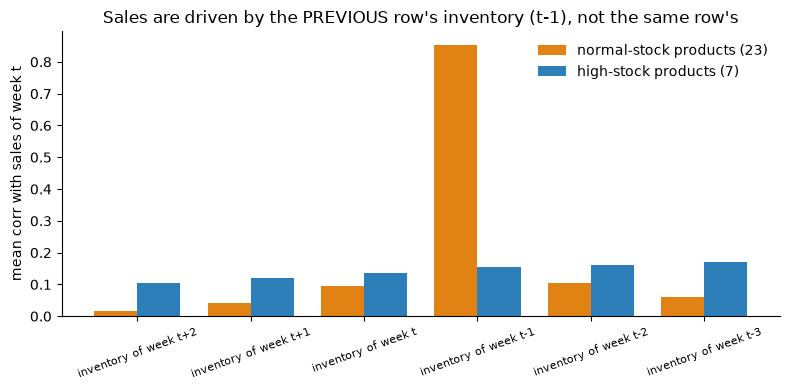

In [13]:
# Evidence for the inventory-timing finding (all numbers computed from the clean fact table)
fa = after_df.merge(dim_product[["product_id", "inventory_profile"]], on="product_id")
fa = fa.sort_values(["product_id", "week_id"])
known = fa["stock_available_for_sales"].notna()
k_ = fa[known]
timing_evidence = pd.DataFrame([
    ("Rows with stock known (weeks 2..260)", int(known.sum())),
    ("Same-row view: sales > inventory_level", int((fa.sales_units > fa.inventory_level).sum())),
    ("Offset view: sales > previous-row inventory", int((k_.sales_units > k_.stock_available_for_sales).sum())),
    ("Same-row view: inventory = 0 but sales > 0", int(((fa.inventory_level == 0) & (fa.sales_units > 0)).sum())),
    ("Offset view: stock available = 0 weeks", int((k_.stock_available_for_sales == 0).sum())),
    ("  ...of which sales = 0", int(((k_.stock_available_for_sales == 0) & (k_.sales_units == 0)).sum())),
    ("Stock-limited weeks (sales >= stock > 0)", int(fa.flag_stock_limited.sum())),
    ("Unconstrained weeks (sales < stock)", int((k_.sales_units < k_.stock_available_for_sales).sum())),
    ("Share of all known weeks that are censored", round(float(1 - (k_.sales_units < k_.stock_available_for_sales).mean()), 3)),
], columns=["Metric", "Value"])
display(timing_evidence)

lagcorr = {}
for prof, g in fa.groupby("inventory_profile"):
    vals = {}
    for lag in range(-2, 4):
        c = [x.sales_units.corr(x.inventory_level.shift(lag)) for _, x in g.groupby("product_id")]
        vals[lag] = np.nanmean(c)
    lagcorr[prof] = vals
lagcorr = pd.DataFrame(lagcorr)
fig, ax = plt.subplots(figsize=(8, 4))
w = 0.38; xs = np.arange(len(lagcorr))
ax.bar(xs - w / 2, lagcorr["normal"], w, color=ORANGE if "ORANGE" in globals() else "#e08214", label="normal-stock products (23)")
ax.bar(xs + w / 2, lagcorr["high_stock"], w, color="#2c7fb8", label="high-stock products (7)")
ax.set_xticks(xs); ax.set_xticklabels([f"inventory of week t-{l}" if l > 0 else ("inventory of week t" if l == 0 else f"inventory of week t+{-l}") for l in lagcorr.index], rotation=20, fontsize=8)
ax.set_ylabel("mean corr with sales of week t"); ax.set_title("Sales are driven by the PREVIOUS row's inventory (t-1), not the same row's")
ax.legend(frameon=False); fig.tight_layout(); fig.savefig(FIG / f"inventory_timing_{VERSION}.png"); plt.show()

In [14]:
QUERIES = {
    "Revenue & gross margin by data year": """
        SELECT d.year_index AS data_year, MIN(d.year) AS calendar_year, ROUND(SUM(f.revenue), 0) AS revenue,
               ROUND(SUM(f.gross_profit), 0) AS gross_profit,
               ROUND(100.0 * SUM(f.gross_profit) / SUM(f.revenue), 2) AS gross_margin_pct
        FROM fact_weekly_sales f JOIN dim_date d USING (week_id) GROUP BY d.year_index ORDER BY d.year_index""",
    "Top 5 products by revenue": """
        SELECT product_name, product_category, total_units, total_revenue, gross_profit_margin
        FROM vw_product_summary ORDER BY total_revenue DESC LIMIT 5""",
    "High-stock products (weeks of cover)": """
        SELECT product_name, avg_inventory, avg_weeks_of_cover, total_revenue
        FROM vw_product_summary WHERE inventory_profile = 'high_stock' ORDER BY avg_weeks_of_cover DESC""",
    "Revenue by category and season": """
        SELECT product_category, season, ROUND(SUM(revenue), 0) AS revenue
        FROM vw_sales_enriched GROUP BY product_category, season ORDER BY product_category, season""",
    "Products with most stock-constrained weeks": """
        SELECT product_name, zero_sales_weeks, stockout_weeks, stock_limited_weeks FROM vw_product_summary
        ORDER BY stockout_weeks + stock_limited_weeks DESC LIMIT 5""",
}
query_results = {name: pd.read_sql(sql, conn) for name, sql in QUERIES.items()}
for name, r in query_results.items():
    print(f"\n-- {name}"); print(r.to_string(index=False))


-- Revenue & gross margin by data year
 data_year  calendar_year    revenue  gross_profit  gross_margin_pct
         1           2020 61945971.0    13280577.0             21.44
         2           2021 61931151.0    13346268.0             21.55
         3           2022 62488966.0    13541596.0             21.67
         4           2023 63258879.0    13629303.0             21.55
         5           2024 65353105.0    14037387.0             21.48

-- Top 5 products by revenue
   product_name product_category  total_units  total_revenue  gross_profit_margin
       Palm Oil      Oils & Fats       384514    21506389.68               0.2146
  Lentils - Red           Pulses       331928    20542085.76               0.2148
   Rice - White Cereals & Grains       336999    20492004.24               0.2140
Lentils - Green           Pulses       353996    19106829.98               0.2149
           Oats Cereals & Grains       365556    18776801.72               0.2148

-- High-stock products 

## 12. Figures

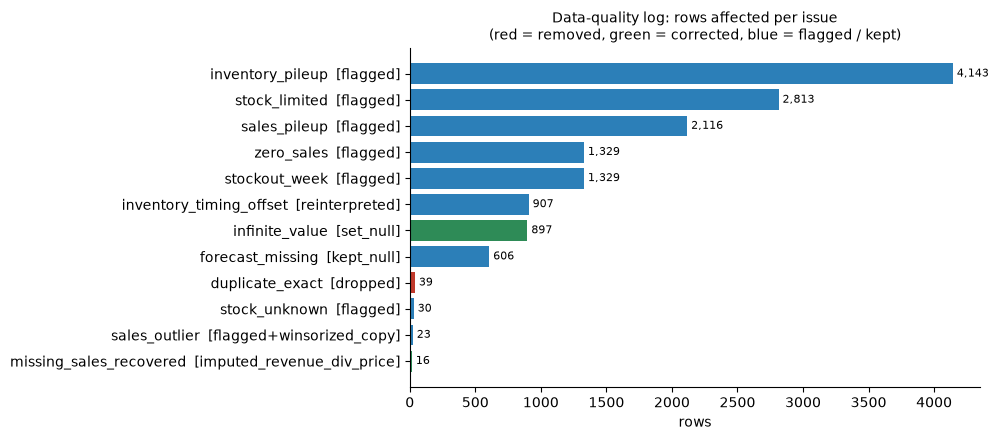

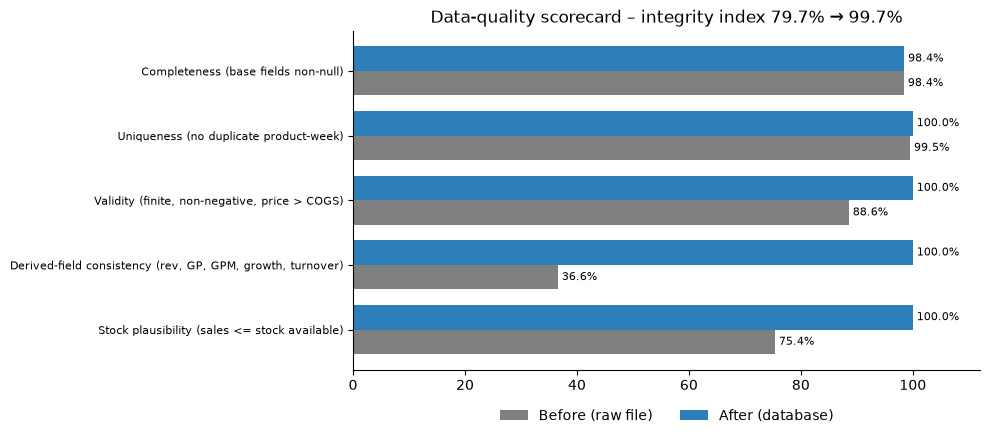

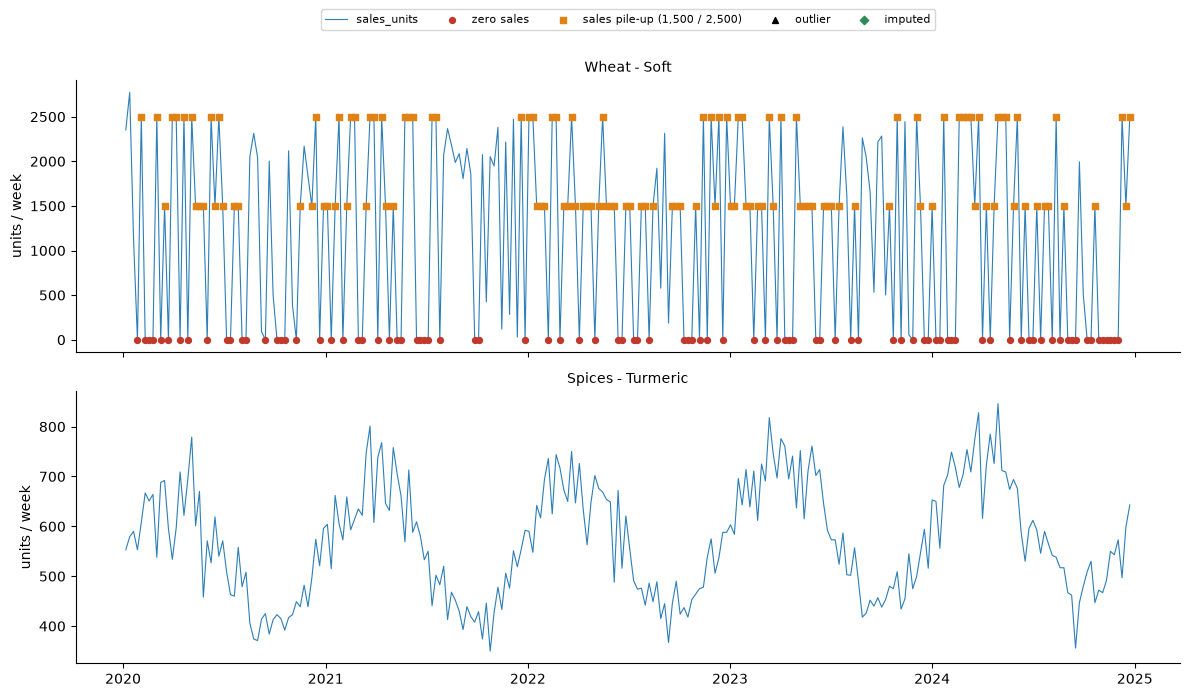

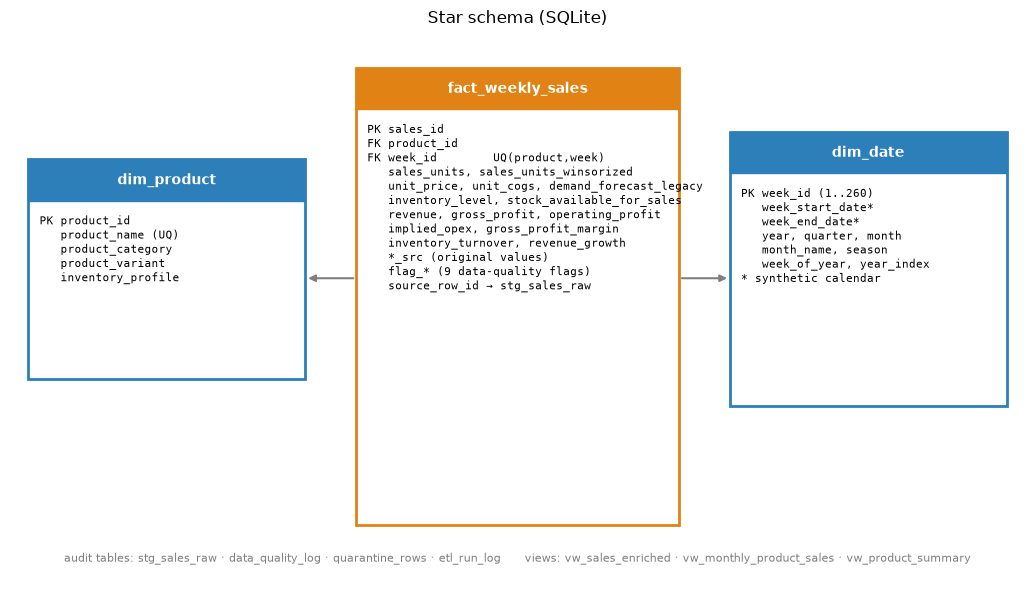

In [15]:
BLUE, ORANGE, GREY, RED, GREEN = "#2c7fb8", "#e08214", "#7f7f7f", "#c0392b", "#2e8b57"
dq = ctx.dq

# 1) data-quality log summary
dq_sum = dq.groupby(["issue_type", "action"]).size().reset_index(name="rows").sort_values("rows")
color_of = lambda a: RED if "dropped" in a or "removed" in a else (GREEN if ("imputed" in a or "recomputed" in a or "set_null" in a or "rounded" in a) else BLUE)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.barh(dq_sum.issue_type + "  [" + dq_sum.action + "]", dq_sum.rows, color=[color_of(a) for a in dq_sum.action])
for y, v in enumerate(dq_sum.rows):
    ax.text(v, y, f" {v:,}", va="center", fontsize=8)
ax.set_title("Data-quality log: rows affected per issue\n(red = removed, green = corrected, blue = flagged / kept)", fontsize=10)
ax.set_xlabel("rows"); fig.tight_layout(); fig.savefig(FIG / f"dq_issues_{VERSION}.png"); plt.show()

# 2) scorecard before vs after
s2 = sc.drop(index="INTEGRITY INDEX (mean of 5)") * 100
fig, ax = plt.subplots(figsize=(10, 4.5))
y = np.arange(len(s2)); h = 0.38
ax.barh(y + h / 2, s2.iloc[:, 0], h, color=GREY, label="Before (raw file)")
ax.barh(y - h / 2, s2.iloc[:, 1], h, color=BLUE, label="After (database)")
for yy, (a, b) in enumerate(zip(s2.iloc[:, 0], s2.iloc[:, 1])):
    ax.text(a, yy + h / 2, f" {a:.1f}%", va="center", fontsize=8); ax.text(b, yy - h / 2, f" {b:.1f}%", va="center", fontsize=8)
ax.set_yticks(y); ax.set_yticklabels(s2.index, fontsize=8); ax.invert_yaxis(); ax.set_xlim(0, 112)
idx_b, idx_a = (sc.loc["INTEGRITY INDEX (mean of 5)"] * 100).round(1)
ax.set_title(f"Data-quality scorecard – integrity index {idx_b}% → {idx_a}%"); ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=2, frameon=False)
fig.tight_layout(); fig.savefig(FIG / f"scorecard_{VERSION}.png"); plt.show()

# 3) flagged points on two example products
ex = after_df.merge(dim_date[["week_id", "week_start_date"]], on="week_id")
ex["week_start_date"] = pd.to_datetime(ex["week_start_date"])
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for ax, p in zip(axes, ["Wheat - Soft", "Spices - Turmeric"]):
    g = ex[ex.product_name == p].sort_values("week_id")
    ax.plot(g.week_start_date, g.sales_units, color=BLUE, lw=.8, label="sales_units")
    for flag, col, mk, lab in [("flag_zero_sales", RED, "o", "zero sales"), ("flag_sales_pileup", ORANGE, "s", "sales pile-up (1,500 / 2,500)"),
                               ("flag_sales_outlier", "black", "^", "outlier"), ("flag_sales_imputed", GREEN, "D", "imputed")]:
        gg = g[g[flag] == 1]
        ax.scatter(gg.week_start_date, gg.sales_units, c=col, marker=mk, s=18, label=lab, zorder=3)
    ax.set_title(p, fontsize=10); ax.set_ylabel("units / week")
axes[0].legend(ncol=5, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, 1.28))
fig.tight_layout(); fig.savefig(FIG / f"flagged_sales_examples_{VERSION}.png"); plt.show()

# 4) ER diagram
fig, ax = plt.subplots(figsize=(11, 6)); ax.axis("off"); ax.set_xlim(0, 11); ax.set_ylim(0, 6)
def box(x, y, w, h, title, lines, color):
    ax.add_patch(plt.Rectangle((x, y), w, h, fc="white", ec=color, lw=2))
    ax.add_patch(plt.Rectangle((x, y + h - .45), w, .45, fc=color, ec=color))
    ax.text(x + w / 2, y + h - .23, title, ha="center", va="center", color="white", fontweight="bold", fontsize=10)
    ax.text(x + .12, y + h - .6, "\n".join(lines), va="top", fontsize=8, family="monospace")
box(0.2, 2.2, 3.0, 2.4, "dim_product", ["PK product_id", "   product_name (UQ)", "   product_category", "   product_variant", "   inventory_profile"], BLUE)
box(7.8, 1.9, 3.0, 3.0, "dim_date", ["PK week_id (1..260)", "   week_start_date*", "   week_end_date*", "   year, quarter, month", "   month_name, season", "   week_of_year, year_index", "* synthetic calendar"], BLUE)
box(3.75, 0.6, 3.5, 5.0, "fact_weekly_sales", ["PK sales_id", "FK product_id", "FK week_id        UQ(product,week)", "   sales_units, sales_units_winsorized", "   unit_price, unit_cogs, demand_forecast_legacy", "   inventory_level, stock_available_for_sales", "   revenue, gross_profit, operating_profit", "   implied_opex, gross_profit_margin", "   inventory_turnover, revenue_growth", "   *_src (original values)", "   flag_* (9 data-quality flags)", "   source_row_id → stg_sales_raw"], ORANGE)
ax.annotate("", xy=(3.2, 3.3), xytext=(3.75, 3.3), arrowprops=dict(arrowstyle="-|>", color=GREY, lw=1.5))
ax.annotate("", xy=(7.8, 3.3), xytext=(7.25, 3.3), arrowprops=dict(arrowstyle="-|>", color=GREY, lw=1.5))
ax.text(5.5, 0.2, "audit tables: stg_sales_raw · data_quality_log · quarantine_rows · etl_run_log      views: vw_sales_enriched · vw_monthly_product_sales · vw_product_summary", ha="center", fontsize=8, color=GREY)
ax.set_title("Star schema (SQLite)"); fig.tight_layout(); fig.savefig(FIG / f"star_schema_{VERSION}.png"); plt.show()

## 13. Export to Excel
`etl_results_v1.2.xlsx`: Summary (first sheet), data-quality scorecard, flags, inventory-timing evidence, exception tests, validation, data dictionary and assumptions. The full log, fact table and dimensions are in the database and the log file.

In [16]:
from openpyxl import load_workbook
from openpyxl.drawing.image import Image as XLImage
from openpyxl.styles import Alignment, Font, PatternFill
from openpyxl.utils import get_column_letter

cnt = dq.groupby("issue_type").size().to_dict()
n_raw = len(raw_orig)
summary = pd.DataFrame([
    ("Input", "Raw rows read", n_raw, "Extract with file + schema checks; untouched copy stored in stg_sales_raw", f"{n_raw:,} rows staged"),
    ("Uniqueness", "Exact duplicate rows", cnt.get("duplicate_exact", 0), "Dropped, first occurrence kept (logged)", f"{len(fact):,} unique product-weeks"),
    ("Uniqueness", "Conflicting duplicate keys", cnt.get("conflicting_duplicate_key", 0), "Would be quarantined (none in this file)", "-"),
    ("Completeness", "Missing Sales_Units", cnt.get("missing_sales_recovered", 0), "Recovered as ROUND(Revenue / Price); flag_sales_imputed = 1", "0 NULL sales_units"),
    ("Completeness", "Missing Demand_Forecast", cnt.get("forecast_missing", 0), "Kept NULL + flag_forecast_missing (legacy baseline, not imputed)", "Flagged"),
    ("Validity", "Infinite Revenue_Growth (source)", cnt.get("infinite_value", 0), "Set NULL, growth recomputed (NULL when prior revenue = 0 or first week)", "No inf in database"),
    ("Consistency", "Inventory_Turnover_Ratio definition", int((after_df.inventory_turnover_src.notna()).sum()), "Original kept as inventory_turnover_src; recomputed = units sold / stock available for those sales (= COGS sold / stock at cost)", "Documented definition"),
    ("Consistency", "Derived-column mismatches", cnt.get("derived_mismatch", 0), "Revenue, Gross_Profit, GPM recomputed from clean inputs", "100% reproducible"),
    ("Inventory timing", "Same-row inventory = 0 but Sales > 0", cnt.get("inventory_timing_offset", 0), "Explained: sales in week t are limited by the PREVIOUS row's inventory -> stock_available_for_sales added", "0 sales > stock available"),
    ("Inventory timing", "Stock-out weeks (stock available = 0)", cnt.get("stockout_week", 0), "Flagged (flag_stockout_week); every one has sales = 0", "Censored demand identified"),
    ("Inventory timing", "Stock-limited weeks (sales = stock)", cnt.get("stock_limited", 0), "Flagged (flag_stock_limited); true demand >= sales", "Censored demand identified"),
    ("Plausibility", "Zero-sales weeks", cnt.get("zero_sales", 0), "Flagged (flag_zero_sales), kept - all are stock-out weeks", "Flagged"),
    ("Plausibility", "Sales pile-up at 1,500 / 2,500", cnt.get("sales_pileup", 0), "Flagged (flag_sales_pileup), kept - sales capped by available stock", "Flagged"),
    ("Plausibility", "Inventory pile-up at 0 / 1,500 / 2,500", cnt.get("inventory_pileup", 0), "Flagged (flag_inventory_pileup), kept", "Flagged"),
    ("Outliers", "Sales outliers (|robust z| > 4)", cnt.get("sales_outlier", 0), "Flagged; winsorised copy in sales_units_winsorized, original untouched", "Modelling column added"),
    ("Corruption", "Rows quarantined", len(ctx.quarantined), "Unusable rows moved to quarantine_rows with reason + raw JSON", f"Handling proven by {len(exception_tests)} injected-fault tests"),
    ("Dates", "Calendar", CONFIG["n_weeks"], f"Synthetic: week 1 = {CONFIG['start_date']} (assumption)", "dim_date, 260 weeks"),
    ("Result", "Rows in fact_weekly_sales", len(fact), "30 products x 260 weeks, star schema in SQLite", f"Integrity index {idx_b}% -> {idx_a}%"),
], columns=["Area", "Issue / step", "Rows affected", "Treatment applied", "Outcome"])
summary.insert(0, "#", range(1, len(summary) + 1))

DESC = {
    "sales_id": "Surrogate key", "product_id": "FK to dim_product", "week_id": "FK to dim_date (1..260)",
    "sales_units": "Units sold (missing values recovered from Revenue / Price)",
    "sales_units_winsorized": "Sales clipped at median +/- 4 robust SD per product (modelling copy; original kept)",
    "unit_price": "Selling price per unit", "unit_cogs": "Unit acquisition cost (COGS)",
    "inventory_level": "Stock available at the beginning of the week (units)",
    "demand_forecast_legacy": "Legacy baseline forecast from the source (NULL where missing)",
    "revenue": "Recomputed = sales_units x unit_price", "gross_profit": "Recomputed = revenue - sales_units x unit_cogs",
    "operating_profit": "As provided (opex not given)", "implied_opex": "gross_profit - operating_profit",
    "gross_profit_margin": "gross_profit / revenue (NULL when revenue = 0)",
    "inventory_turnover": "sales_units / stock_available_for_sales (NULL when stock = 0)",
    "stock_available_for_sales": "Previous row's inventory_level = stock that limits this week's sales (NULL in week 1)",
    "revenue_growth": "Week-over-week revenue growth per product (NULL for week 1 or when prior revenue = 0)",
    "inventory_turnover_src": "Original source value (clipped to [0, 1], definition unknown)",
    "revenue_growth_src": "Original source value (inf replaced with NULL)",
    "flag_sales_imputed": "1 = Sales_Units recovered", "flag_zero_sales": "1 = Sales_Units = 0",
    "flag_sales_pileup": "1 = Sales_Units exactly 1,500 or 2,500", "flag_inventory_pileup": "1 = Inventory exactly 0 / 1,500 / 2,500",
    "flag_stockout_week": "1 = stock available = 0 (sales forced to 0)", "flag_stock_limited": "1 = sales >= stock available (> 0): censored demand",
    "flag_stock_unknown": "1 = week 1, stock unknown", "flag_sales_outlier": "1 = |robust z| > 4",
    "flag_forecast_missing": "1 = Demand_Forecast missing", "source_row_id": "Row number in stg_sales_raw (lineage)",
    "product_name": "Commodity name (trimmed)", "product_category": "ASSUMPTION: category derived from name",
    "product_variant": "Part after ' - ' in the name", "inventory_profile": "'high_stock' if mean inventory / mean weekly sales > 5",
    "week_start_date": "Synthetic Monday start (assumption)", "week_end_date": "week_start_date + 6 days",
    "year": "Calendar year (synthetic)", "quarter": "Calendar quarter", "month": "Calendar month", "month_name": "Month name",
    "week_of_year": "1..52 position within the data year", "season": "Northern-hemisphere season of week_start_date",
    "year_index": "Data year 1..5 (52-week blocks)",
}
dict_rows = []
for t in ["dim_product", "dim_date", "fact_weekly_sales", "data_quality_log", "quarantine_rows", "etl_run_log"]:
    for cid, name, typ, notnull, _dflt, pk in conn.execute(f"PRAGMA table_info({t})").fetchall():
        dict_rows.append((t, name, typ, "PK" if pk else ("NOT NULL" if notnull else "NULL"), DESC.get(name, "")))
data_dictionary = pd.DataFrame(dict_rows, columns=["table", "column", "type", "constraint", "description"])

assumptions = pd.DataFrame([
    ("A1", "Dates", "Source has only Week 1-260; a synthetic calendar is used (week 1 = Monday 2020-01-06). Calendar attributes (year, month, season) are therefore illustrative."),
    ("A2", "Flag, don't delete", "Zero-sales, pile-up, inventory-inconsistent and outlier rows are kept and flagged so downstream models/pricing can decide."),
    ("A3", "Duplicates", "A row duplicated on (product, week) with identical values is a load duplicate; with different values it is ambiguous and quarantined."),
    ("A4", "Sales recovery", "Revenue = Sales x Price holds for 100% of rows, so missing Sales_Units = ROUND(Revenue / Price)."),
    ("A5", "Demand_Forecast", "Legacy baseline; missing values are NOT imputed (it is only a benchmark / feature)."),
    ("A6", "Derived KPIs", "Revenue, Gross_Profit, GPM, turnover and growth are recomputed; originals of turnover/growth kept as *_src."),
    ("A7", "Inventory turnover", "Defined as units sold / stock available for those sales (= COGS sold / stock valued at unit COGS); source definition unknown."),
    ("A8", "Outliers", "Per-product robust z-score (median / MAD) > 4; flagged and winsorised in a separate column only."),
    ("A9", "Pile-ups at 1,500 / 2,500", "Sales capped by available stock (sales never exceed the previous row's inventory); demand in those weeks is right-censored."),
    ("A10", "Product categories", "Not in the source; mapped manually from product names (CATEGORY_MAP)."),
    ("A11", "Operating profit", "Opex not provided; implied_opex = gross_profit - operating_profit."),
    ("A12", "Database", "SQLite, rebuilt from scratch on every run (idempotent); loaded in a single transaction."),
    ("A13", "Inventory timing (v1.2)", "Inventory_Level in row t-1 is the stock available for week t's sales (sales never exceed it, stock = 0 always means sales = 0). Treated as a one-week offset in the source; original inventory_level is kept unchanged."),
], columns=["#", "Topic", "Assumption"])

XLSX = XLSX_PATH
sheets_all = {
    "Summary": summary, "Run_Log": ctx.run_log.drop(columns=["started_utc"]).rename_axis("#").reset_index(),
    "Scorecard": scorecard_table, "Flags": flag_summary, "Inventory_Timing": timing_evidence,
    "DQ_Summary": dq.groupby(["issue_type", "column_name", "action"], dropna=False).size().reset_index(name="rows").sort_values("rows", ascending=False),
    "DQ_Log": dq, "Quarantine": ctx.quarantined, "Exception_Tests": exception_tests, "Validation": validation,
    "Data_Dictionary": data_dictionary, "Assumptions": assumptions,
    "dim_product": dim_product.drop(columns="weeks_cover").assign(weeks_of_cover=dim_product.weeks_cover.round(1)),
    "dim_date": dim_date, "fact_weekly_sales": fact,
}
KEEP = ["Summary", "Scorecard", "Flags", "Inventory_Timing", "Exception_Tests", "Validation", "Data_Dictionary", "Assumptions"]
sheets = {k: sheets_all[k] for k in KEEP}
with pd.ExcelWriter(XLSX, engine="openpyxl") as xw:
    for name, t in sheets.items():
        t.to_excel(xw, sheet_name=name[:31], index=False)

wb = load_workbook(XLSX)
head_fill = PatternFill("solid", fgColor="1F4E79")
for ws in wb.worksheets:
    for cell in ws[1]:
        cell.font = Font(bold=True, color="FFFFFF"); cell.fill = head_fill
        cell.alignment = Alignment(horizontal="center", vertical="center")
    ws.freeze_panes = "A2"
    for i, col in enumerate(ws.columns, 1):
        width = max(len(str(c.value)) if c.value is not None else 0 for c in list(col)[:300])
        ws.column_dimensions[get_column_letter(i)].width = min(max(width + 2, 8), 70)
for name, widths in {"Summary": [5, 14, 36, 14, 80, 36], "Assumptions": [6, 24, 130], "Data_Dictionary": [20, 28, 10, 12, 95]}.items():
    for col, w in zip("ABCDEF", widths):
        wb[name].column_dimensions[col].width = w
    for r in wb[name].iter_rows(min_row=2):
        for c in r: c.alignment = Alignment(wrap_text=True, vertical="top")
for c in wb["Validation"]["D"][1:] + wb["Exception_Tests"]["D"][1:]:
    c.fill = PatternFill("solid", fgColor="C6E0B4" if c.value else "F8CBAD")
wb.save(XLSX)
print("Saved:", XLSX.name, "| sheets:", wb.sheetnames)
conn.close()

Saved: etl_results_v1.2.xlsx | sheets: ['Summary', 'Scorecard', 'Flags', 'Inventory_Timing', 'Exception_Tests', 'Validation', 'Data_Dictionary', 'Assumptions']


## 14. Outputs
| File | Purpose |
|---|---|
| `part1_etl_pipeline_v1.2/armani_trade_v1.2.db` | SQLite database (star schema, staging, audit tables, views) |
| `part1_etl_pipeline_v1.2/schema_v1.2.sql` | DDL for all tables, indexes and views |
| `part1_etl_pipeline_v1.2/etl_results_v1.2.xlsx` | Results workbook (first sheet = Summary) |
| `part1_etl_pipeline_v1.2/etl_run_v1.2.log`, `figures/` | Execution log, charts |